Model 1: 1500 points | wall=54.8min | peak reward=31.7 | final=30.9
Model 2: 1500 points | wall=8.2min | peak reward=28.6 | final=-219.2


C:\Users\edward\AppData\Local\Temp\ipykernel_28488\3039328261.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


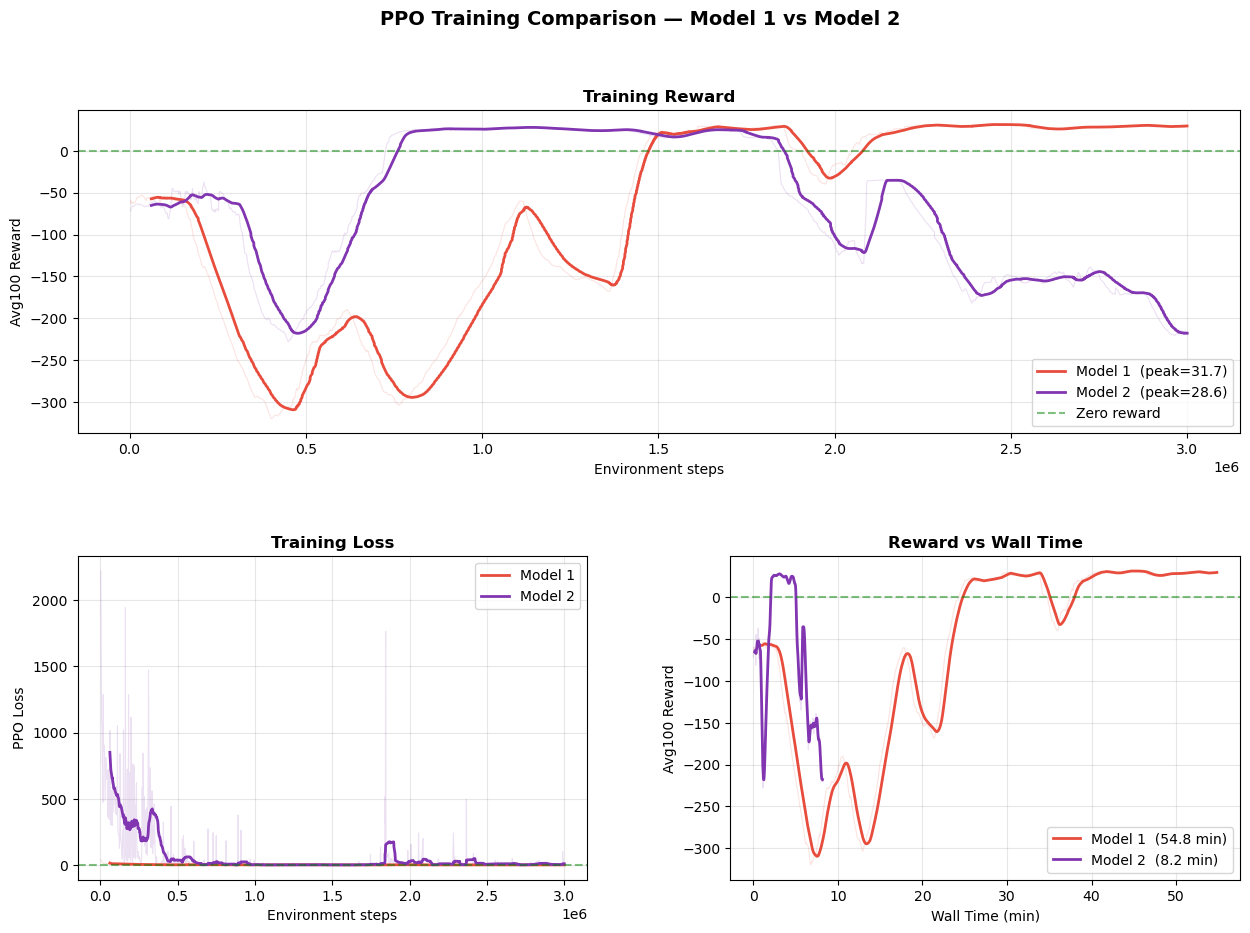


Saved: Ed/ppo_comparison.png

  Summary
                             Model 1       Model 2
  Wall time (min)               54.8           8.2
  Total steps              3,000,000     3,000,320
  Peak reward                   31.7          28.6
  Final reward                  30.9        -219.2


In [3]:
"""
plot_compare.py
---------------
Compares two PPO training runs on the same plot.

  Model 1: PPO_cmp_seed42.json          (uses "rows" key)
  Model 2: cmp_PPO_seedcmp_seed42.json  (uses "timeseries" key)

Run:  python plot_compare.py
Output saved to Ed/ppo_comparison.png
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── UPDATE THESE ──────────────────────────────────────────────────────────────
LOG_PATH_1  = r"Ed/SavedSeeds/PPO_cmp_seed42.json"
LOG_PATH_2  = r"C:\Users\edward\OneDrive - City University of Hong Kong\uw\me569\owsbr\Arthur\Ozzy_Segway_Data\SavedSeeds\cmp_PPO_seedcmp_seed42.json"
LABEL_1     = "Model 1"
LABEL_2     = "Model 2"
OUTPUT_DIR  = r"Ed"
# ─────────────────────────────────────────────────────────────────────────────

COLOR_1 = "#E74C3C"   # red
COLOR_2 = "#8135B1"   # blue


def load_model1(path):
    """PPO_cmp_seed42.json — uses 'rows' key."""
    with open(path) as f:
        d = json.load(f)
    rows = d["rows"]
    return {
        "steps":     [r["steps"]       for r in rows],
        "rewards":   [r["avg_reward"]  for r in rows],
        "losses":    [r["loss"]        for r in rows],
        "wall_time": d.get("total_wall_time", 0),
    }


def load_model2(path):
    """cmp_PPO_seedcmp_seed42.json — uses 'timeseries' key."""
    with open(path) as f:
        d = json.load(f)
    ts = d["timeseries"]
    return {
        "steps":     [r["steps"]       for r in ts],
        "rewards":   [r["avg_reward"]  for r in ts],
        "losses":    [r["loss"]        for r in ts],
        "wall_time": d.get("total_wall_time", 0),
    }


def smooth(values, w=20):
    """Simple moving average for cleaner curves."""
    if len(values) < w:
        return values
    kernel = np.ones(w) / w
    return np.convolve(values, kernel, mode="valid")


def smooth_steps(steps, w=20):
    """Trim steps to match smoothed length."""
    if len(steps) < w:
        return steps
    return steps[w-1:]


# ── load ──────────────────────────────────────────────────────────────────────
m1 = load_model1(LOG_PATH_1)
m2 = load_model2(LOG_PATH_2)

print(f"{LABEL_1}: {len(m1['steps'])} points | "
      f"wall={m1['wall_time']/60:.1f}min | "
      f"peak reward={max(m1['rewards']):.1f} | "
      f"final={m1['rewards'][-1]:.1f}")
print(f"{LABEL_2}: {len(m2['steps'])} points | "
      f"wall={m2['wall_time']/60:.1f}min | "
      f"peak reward={max(m2['rewards']):.1f} | "
      f"final={m2['rewards'][-1]:.1f}")

# ── plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.28, figure=fig)
fig.suptitle("PPO Training Comparison — Model 1 vs Model 2",
             fontsize=14, fontweight="bold")

W = 30   # smoothing window

# ── reward (top row, full width) ──────────────────────────────────────────────
ax = fig.add_subplot(gs[0, :])
# raw (faint)
ax.plot(m1["steps"], m1["rewards"], color=COLOR_1, alpha=0.15, lw=0.8)
ax.plot(m2["steps"], m2["rewards"], color=COLOR_2, alpha=0.15, lw=0.8)
# smoothed
ax.plot(smooth_steps(m1["steps"], W), smooth(m1["rewards"], W),
        color=COLOR_1, lw=2, label=f"{LABEL_1}  (peak={max(m1['rewards']):.1f})")
ax.plot(smooth_steps(m2["steps"], W), smooth(m2["rewards"], W),
        color=COLOR_2, lw=2, label=f"{LABEL_2}  (peak={max(m2['rewards']):.1f})")
ax.axhline(0, color="green", ls="--", alpha=0.5, label="Zero reward")
ax.set_xlabel("Environment steps"); ax.set_ylabel("Avg100 Reward")
ax.set_title("Training Reward", fontweight="bold")
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# ── loss (bottom-left) ────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.plot(m1["steps"], m1["losses"], color=COLOR_1, alpha=0.15, lw=0.8)
ax.plot(m2["steps"], m2["losses"], color=COLOR_2, alpha=0.15, lw=0.8)
ax.plot(smooth_steps(m1["steps"], W), smooth(m1["losses"], W),
        color=COLOR_1, lw=2, label=LABEL_1)
ax.plot(smooth_steps(m2["steps"], W), smooth(m2["losses"], W),
        color=COLOR_2, lw=2, label=LABEL_2)
ax.axhline(0, color="green", ls="--", alpha=0.5)
ax.set_xlabel("Environment steps"); ax.set_ylabel("PPO Loss")
ax.set_title("Training Loss", fontweight="bold")
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# ── reward vs wall time (bottom-right) ───────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
# derive wall time per log point
wt1 = np.linspace(0, m1["wall_time"]/60, len(m1["steps"]))
wt2 = np.linspace(0, m2["wall_time"]/60, len(m2["steps"]))
ax.plot(wt1, m1["rewards"], color=COLOR_1, alpha=0.15, lw=0.8)
ax.plot(wt2, m2["rewards"], color=COLOR_2, alpha=0.15, lw=0.8)
ax.plot(smooth_steps(list(wt1), W), smooth(m1["rewards"], W),
        color=COLOR_1, lw=2,
        label=f"{LABEL_1}  ({m1['wall_time']/60:.1f} min)")
ax.plot(smooth_steps(list(wt2), W), smooth(m2["rewards"], W),
        color=COLOR_2, lw=2,
        label=f"{LABEL_2}  ({m2['wall_time']/60:.1f} min)")
ax.axhline(0, color="green", ls="--", alpha=0.5)
ax.set_xlabel("Wall Time (min)"); ax.set_ylabel("Avg100 Reward")
ax.set_title("Reward vs Wall Time", fontweight="bold")
ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout()
out = OUTPUT_DIR + "/ppo_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {out}")

# ── summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  Summary")
print(f"{'='*50}")
print(f"  {'':20s}  {LABEL_1:>12}  {LABEL_2:>12}")
print(f"  {'Wall time (min)':20s}  {m1['wall_time']/60:>12.1f}  {m2['wall_time']/60:>12.1f}")
print(f"  {'Total steps':20s}  {max(m1['steps']):>12,}  {max(m2['steps']):>12,}")
print(f"  {'Peak reward':20s}  {max(m1['rewards']):>12.1f}  {max(m2['rewards']):>12.1f}")
print(f"  {'Final reward':20s}  {m1['rewards'][-1]:>12.1f}  {m2['rewards'][-1]:>12.1f}")
print(f"{'='*50}")


  PPO Comparison Plotter

Model 1: peak=31.7  wall=54.8min
Model 2: peak=28.6  wall=8.2min

[1/3] Training curves...


C:\Users\edward\AppData\Local\Temp\ipykernel_28488\2075783023.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


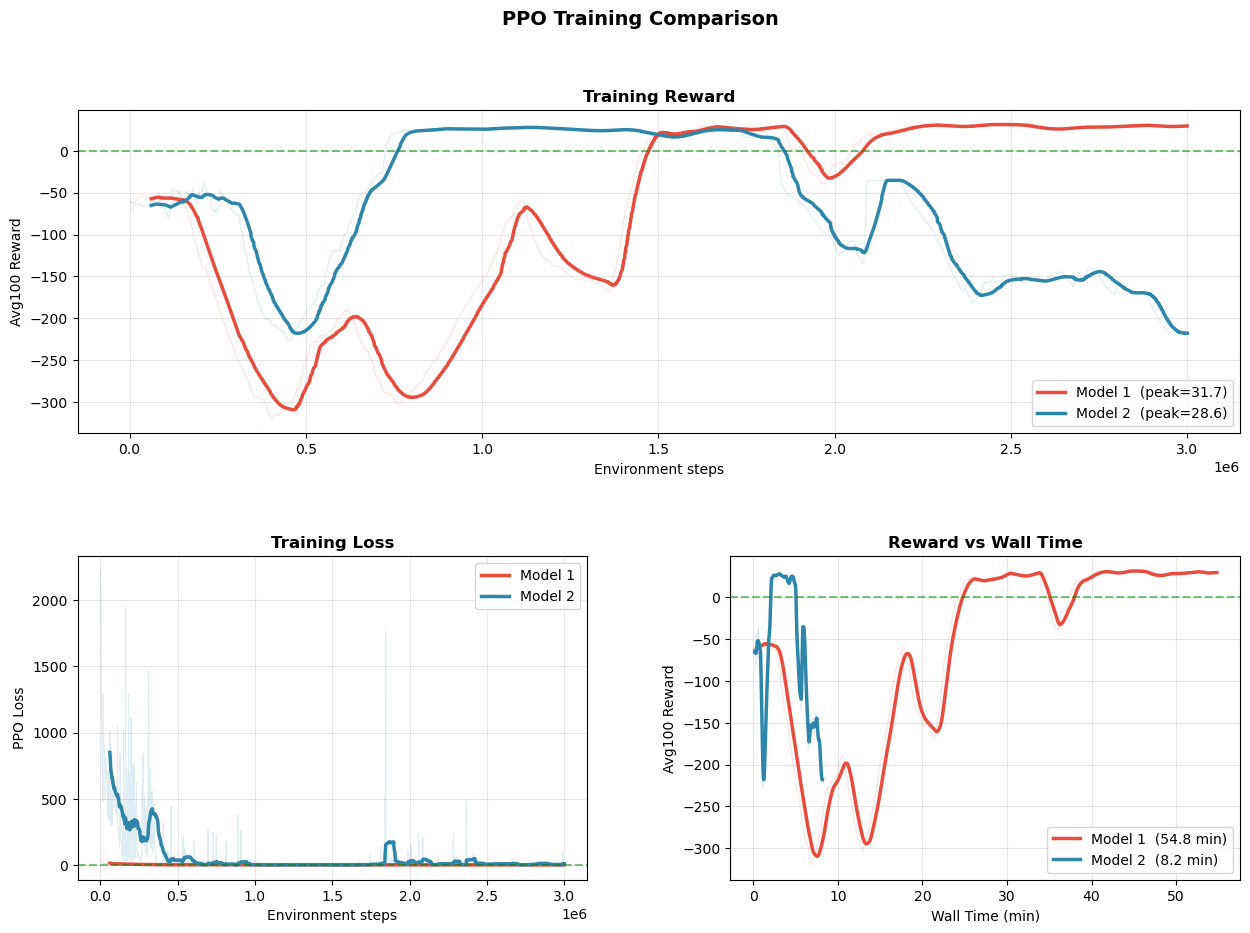

Saved: Ed/ppo_comparison.png

[2/3] Running episode for Model 1...
  Result: arrived  duration=1.8s  max_x=1.753m

[3/3] Running episode for Model 2...
  Result: arrived  duration=2.0s  max_x=1.753m

Plotting episode traces comparison...


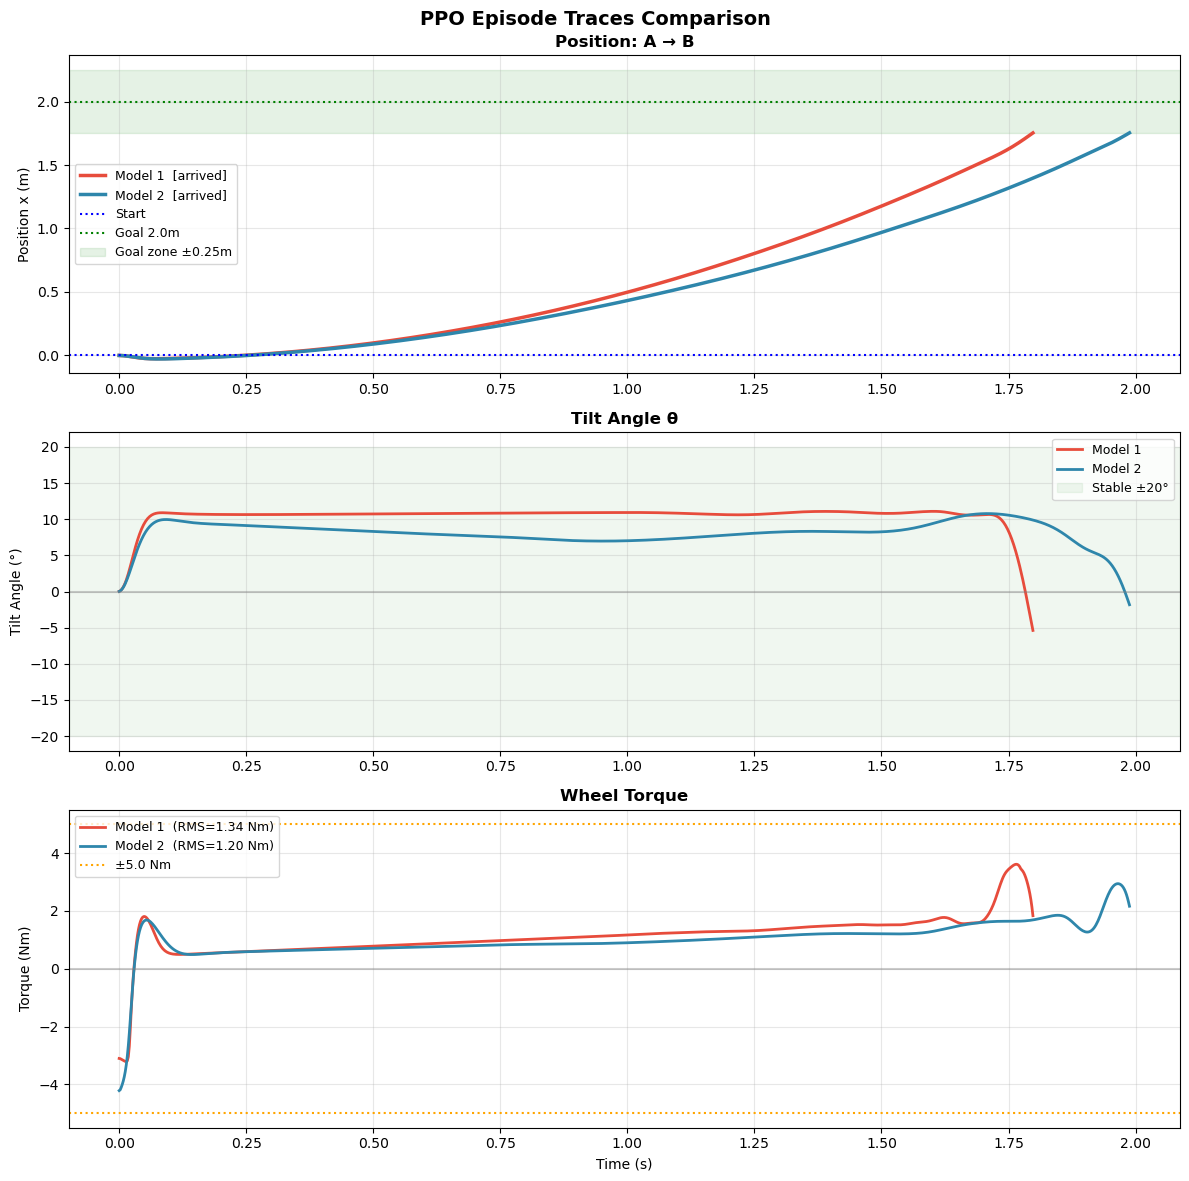

Saved: Ed/ppo_traces_comparison.png

                               Model 1       Model 2
  Duration (s)                     1.8           2.0
  Max x (m)                      1.753         1.753
  Final x (m)                    1.753         1.753
  Avg tilt (deg)                  10.4           8.1
  Torque RMS (Nm)                1.344         1.201
  Result                       arrived       arrived

All done.


In [4]:
"""
plot_compare.py
---------------
Compares two PPO training runs — training curves + episode traces side by side.

Run:  python plot_compare.py
Output saved to Ed/ppo_comparison.png  and  Ed/ppo_traces_comparison.png
"""

import mujoco
import numpy as np
import torch
import torch.nn as nn
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── UPDATE THESE ──────────────────────────────────────────────────────────────
LOG_PATH_1      = r"Ed/SavedSeeds/PPO_cmp_seed42.json"
LOG_PATH_2  = r"C:\Users\edward\OneDrive - City University of Hong Kong\uw\me569\owsbr\Arthur\Ozzy_Segway_Data\SavedSeeds\cmp_PPO_seedcmp_seed42.json"
WEIGHTS_PATH_1  = r"Ed/SavedSeeds/nav_ppo_cmp_seed42.pth"
WEIGHTS_PATH_2  = r"Arthur/Ozzy_Segway_Data/SavedSeeds/nav_cmp_seed42.pth"   # update to model 2 weights
XML_PATH_1      = r"Ed/model/segway_1d_wheel.xml"   # model 1 xml
XML_PATH_2      = r"C:\Users\edward\OneDrive - City University of Hong Kong\uw\me569\owsbr\Ozzy\segway_2.xml"   # model 2 xml (change if different)
LABEL_1         = "Model 1"
LABEL_2         = "Model 2"
OUTPUT_DIR      = r"Ed"
TORQUE_MAX      = 5.0
GROUND_Z        = 0.075
X_NORM, XD_NORM, TH_NORM, THD_NORM = 2.4, 5.0, 1.57, 5.0
X_DONE_LIMIT    = 2.8
TH_DONE         = 0.5
X_GOAL          = 2.0
# ─────────────────────────────────────────────────────────────────────────────

COLOR_1 = "#E74C3C"
COLOR_2 = "#2E86AB"


def get_obs(data):
    qw,qx,qy,qz = data.qpos[3],data.qpos[4],data.qpos[5],data.qpos[6]
    theta = float(np.arcsin(np.clip(2.0*(qw*qy - qz*qx), -1.0, 1.0)))
    return np.array([data.qpos[0], data.qvel[0], theta, data.qvel[4]], dtype=np.float32)

def normalize_obs(obs):
    x,xd,th,thd = obs
    return np.array([
        np.clip(x  /X_NORM,  -1,1),
        np.clip(xd /XD_NORM, -1,1),
        np.clip(th /TH_NORM, -1,1),
        np.clip(thd/THD_NORM,-1,1),
    ], dtype=np.float32)

def smooth(values, w=20):
    if len(values) < w: return values
    return np.convolve(values, np.ones(w)/w, mode="valid")

def smooth_steps(steps, w=20):
    if len(steps) < w: return steps
    return steps[w-1:]


class NavPPO(nn.Module):
    def __init__(self, torque_max=TORQUE_MAX):
        super().__init__(); self.torque_max = torque_max
        self.net = nn.Sequential(
            nn.Linear(5,256), nn.Tanh(),
            nn.Linear(256,256), nn.Tanh(),
            nn.Linear(256,128), nn.Tanh(),
        )
        self.actor_mean    = nn.Linear(128,1)
        self.actor_log_std = nn.Parameter(torch.tensor([-0.5]))
        self.critic        = nn.Linear(128,1)

    def forward(self, x):
        s = self.net(x); return self.actor_mean(s), self.critic(s)

    def get_action(self, obs, goal_x, deterministic=True):
        dist_norm = float(np.clip((goal_x - obs[0]) / 5., -1, 1))
        inp = torch.FloatTensor([*normalize_obs(obs), dist_norm])
        with torch.no_grad():
            mean, val = self(inp)
            std  = self.actor_log_std.exp().clamp(0.1, 2.0)
            dist = torch.distributions.Normal(mean, std)
            raw  = mean if deterministic else dist.rsample()
            torque = torch.tanh(raw) * self.torque_max
        return torque.item(), None, val


def load_model1(path):
    with open(path) as f: d = json.load(f)
    rows = d["rows"]
    return {"steps":   [r["steps"]      for r in rows],
            "rewards": [r["avg_reward"] for r in rows],
            "losses":  [r["loss"]       for r in rows],
            "wall_time": d.get("total_wall_time", 0)}

def load_model2(path):
    with open(path) as f: d = json.load(f)
    ts = d["timeseries"]
    return {"steps":   [r["steps"]      for r in ts],
            "rewards": [r["avg_reward"] for r in ts],
            "losses":  [r["loss"]       for r in ts],
            "wall_time": d.get("total_wall_time", 0)}


def run_episode(weights_path, xml_path):
    net = NavPPO(torque_max=TORQUE_MAX)
    net.load_state_dict(torch.load(weights_path, map_location="cpu"))
    net.eval()
    model = mujoco.MjModel.from_xml_path(xml_path)
    data  = mujoco.MjData(model)
    dt    = model.opt.timestep
    mujoco.mj_resetData(model, data)
    data.qpos[0]=0.0; data.qpos[2]=GROUND_Z
    data.qpos[3:7]=[1,0,0,0]; data.qvel[:]=0.0
    mujoco.mj_forward(model, data)
    obs = get_obs(data)
    ts, xs, ths, torqs = [], [], [], []
    result = "timeout"
    for step in range(3000):
        torque, _, _ = net.get_action(obs, X_GOAL, deterministic=True)
        u = float(np.clip(torque, -TORQUE_MAX, TORQUE_MAX))
        data.ctrl[0] = -u
        mujoco.mj_step(model, data); obs = get_obs(data)
        x, _, th, _ = obs
        ts.append(step*dt); xs.append(x)
        ths.append(np.degrees(th)); torqs.append(torque)
        if abs(x) > X_DONE_LIMIT or abs(th) > TH_DONE:
            result = "fell"; break
        if abs(x - X_GOAL) < 0.25 and abs(th) < 0.35:
            result = "arrived"; break
    return (np.array(ts), np.array(xs), np.array(ths), np.array(torqs), result)


def plot_training(m1, m2):
    W = 30
    fig = plt.figure(figsize=(15, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.28, figure=fig)
    fig.suptitle("PPO Training Comparison", fontsize=14, fontweight="bold")

    ax = fig.add_subplot(gs[0, :])
    ax.plot(m1["steps"], m1["rewards"], color=COLOR_1, alpha=0.15, lw=0.8)
    ax.plot(m2["steps"], m2["rewards"], color=COLOR_2, alpha=0.15, lw=0.8)
    ax.plot(smooth_steps(m1["steps"], W), smooth(m1["rewards"], W),
            color=COLOR_1, lw=2.5, label=f"{LABEL_1}  (peak={max(m1['rewards']):.1f})")
    ax.plot(smooth_steps(m2["steps"], W), smooth(m2["rewards"], W),
            color=COLOR_2, lw=2.5, label=f"{LABEL_2}  (peak={max(m2['rewards']):.1f})")
    ax.axhline(0, color="green", ls="--", alpha=0.5)
    ax.set_xlabel("Environment steps"); ax.set_ylabel("Avg100 Reward")
    ax.set_title("Training Reward", fontweight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[1, 0])
    ax.plot(m1["steps"], m1["losses"], color=COLOR_1, alpha=0.15, lw=0.8)
    ax.plot(m2["steps"], m2["losses"], color=COLOR_2, alpha=0.15, lw=0.8)
    ax.plot(smooth_steps(m1["steps"], W), smooth(m1["losses"], W),
            color=COLOR_1, lw=2.5, label=LABEL_1)
    ax.plot(smooth_steps(m2["steps"], W), smooth(m2["losses"], W),
            color=COLOR_2, lw=2.5, label=LABEL_2)
    ax.axhline(0, color="green", ls="--", alpha=0.5)
    ax.set_xlabel("Environment steps"); ax.set_ylabel("PPO Loss")
    ax.set_title("Training Loss", fontweight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[1, 1])
    wt1 = np.linspace(0, m1["wall_time"]/60, len(m1["steps"]))
    wt2 = np.linspace(0, m2["wall_time"]/60, len(m2["steps"]))
    ax.plot(wt1, m1["rewards"], color=COLOR_1, alpha=0.15, lw=0.8)
    ax.plot(wt2, m2["rewards"], color=COLOR_2, alpha=0.15, lw=0.8)
    ax.plot(smooth_steps(list(wt1), W), smooth(m1["rewards"], W),
            color=COLOR_1, lw=2.5, label=f"{LABEL_1}  ({m1['wall_time']/60:.1f} min)")
    ax.plot(smooth_steps(list(wt2), W), smooth(m2["rewards"], W),
            color=COLOR_2, lw=2.5, label=f"{LABEL_2}  ({m2['wall_time']/60:.1f} min)")
    ax.axhline(0, color="green", ls="--", alpha=0.5)
    ax.set_xlabel("Wall Time (min)"); ax.set_ylabel("Avg100 Reward")
    ax.set_title("Reward vs Wall Time", fontweight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

    plt.tight_layout()
    out = OUTPUT_DIR + "/ppo_comparison.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


def plot_traces_comparison(ep1, ep2):
    ts1, xs1, ths1, torqs1, res1 = ep1
    ts2, xs2, ths2, torqs2, res2 = ep2
    rms1 = np.sqrt(np.mean(torqs1**2))
    rms2 = np.sqrt(np.mean(torqs2**2))

    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)
    fig.suptitle("PPO Episode Traces Comparison", fontsize=14, fontweight="bold")

    ax = axes[0]
    ax.plot(ts1, xs1, color=COLOR_1, lw=2.5, label=f"{LABEL_1}  [{res1}]")
    ax.plot(ts2, xs2, color=COLOR_2, lw=2.5, label=f"{LABEL_2}  [{res2}]")
    ax.axhline(0,      color="blue",  ls=":", lw=1.5, label="Start")
    ax.axhline(X_GOAL, color="green", ls=":", lw=1.5, label=f"Goal {X_GOAL}m")
    ax.axhspan(X_GOAL-0.25, X_GOAL+0.25, alpha=0.1, color="green", label="Goal zone ±0.25m")
    ax.set_ylabel("Position x (m)")
    ax.set_title("Position: A → B", fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax = axes[1]
    ax.plot(ts1, ths1, color=COLOR_1, lw=2, label=LABEL_1)
    ax.plot(ts2, ths2, color=COLOR_2, lw=2, label=LABEL_2)
    ax.axhspan(-20, 20, alpha=0.06, color="green", label="Stable ±20°")
    ax.axhline(0, color="gray", alpha=0.4)
    ax.set_ylabel("Tilt Angle (°)")
    ax.set_title("Tilt Angle θ", fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax = axes[2]
    ax.plot(ts1, torqs1, color=COLOR_1, lw=2, label=f"{LABEL_1}  (RMS={rms1:.2f} Nm)")
    ax.plot(ts2, torqs2, color=COLOR_2, lw=2, label=f"{LABEL_2}  (RMS={rms2:.2f} Nm)")
    ax.axhline( TORQUE_MAX, color="orange", ls=":", lw=1.5, label=f"±{TORQUE_MAX} Nm")
    ax.axhline(-TORQUE_MAX, color="orange", ls=":", lw=1.5)
    ax.axhline(0, color="gray", alpha=0.4)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Torque (Nm)")
    ax.set_title("Wheel Torque", fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plt.tight_layout()
    out = OUTPUT_DIR + "/ppo_traces_comparison.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

    print(f"\n{'='*55}")
    print(f"  {'':22s}  {LABEL_1:>12}  {LABEL_2:>12}")
    print(f"  {'Duration (s)':22s}  {ts1[-1]:>12.1f}  {ts2[-1]:>12.1f}")
    print(f"  {'Max x (m)':22s}  {max(xs1):>12.3f}  {max(xs2):>12.3f}")
    print(f"  {'Final x (m)':22s}  {xs1[-1]:>12.3f}  {xs2[-1]:>12.3f}")
    print(f"  {'Avg tilt (deg)':22s}  {np.mean(np.abs(ths1)):>12.1f}  {np.mean(np.abs(ths2)):>12.1f}")
    print(f"  {'Torque RMS (Nm)':22s}  {rms1:>12.3f}  {rms2:>12.3f}")
    print(f"  {'Result':22s}  {res1:>12}  {res2:>12}")
    print(f"{'='*55}")


if __name__ == "__main__":
    print("=" * 55)
    print("  PPO Comparison Plotter")
    print("=" * 55)

    m1 = load_model1(LOG_PATH_1)
    m2 = load_model2(LOG_PATH_2)
    print(f"\n{LABEL_1}: peak={max(m1['rewards']):.1f}  wall={m1['wall_time']/60:.1f}min")
    print(f"{LABEL_2}: peak={max(m2['rewards']):.1f}  wall={m2['wall_time']/60:.1f}min")

    print("\n[1/3] Training curves...")
    plot_training(m1, m2)

    print("\n[2/3] Running episode for Model 1...")
    try:
        ep1 = run_episode(WEIGHTS_PATH_1, XML_PATH_1)
        print(f"  Result: {ep1[4]}  duration={ep1[0][-1]:.1f}s  max_x={max(ep1[1]):.3f}m")
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback; traceback.print_exc()
        ep1 = None

    print("\n[3/3] Running episode for Model 2...")
    try:
        ep2 = run_episode(WEIGHTS_PATH_2, XML_PATH_2)
        print(f"  Result: {ep2[4]}  duration={ep2[0][-1]:.1f}s  max_x={max(ep2[1]):.3f}m")
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback; traceback.print_exc()
        ep2 = None

    if ep1 and ep2:
        print("\nPlotting episode traces comparison...")
        plot_traces_comparison(ep1, ep2)
    else:
        print("\nSkipping traces — update WEIGHTS_PATH_1 and WEIGHTS_PATH_2 at the top.")

    print("\nAll done.")

In [ ]:
"""
plot_sac_vs_ppo.py
------------------
Compares SAC vs PPO for the same model (Model 1).

Run:  python plot_sac_vs_ppo.py
Output saved to:
  Ed/sac_vs_ppo_training.png
  Ed/sac_vs_ppo_traces.png
"""

import mujoco
import numpy as np
import torch
import torch.nn as nn
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── UPDATE THESE ──────────────────────────────────────────────────────────────
SAC_LOG_PATH     = r"C:/Users/edward/OneDrive - City University of Hong Kong/uw/me569/owsbr/EdSavedSeeds/SAC_cmp_seed42.json"
PPO_LOG_PATH     = r"C:/Users/edward/OneDrive - City University of Hong Kong/uw/me569/owsbr/Ed/SavedSeeds/PPO_cmp_seed42.json"
SAC_WEIGHTS_PATH = r"C:/Users/edward/OneDrive - City University of Hong Kong/uw/me569/owsbr/Ed/SavedSeeds/nav_sac_cmp_seed42.pth"
PPO_WEIGHTS_PATH = r"C:/Users/edward/OneDrive - City University of Hong Kong/uw/me569/owsbr/Ed/SavedSeeds/nav_ppo_cmp_seed42.pth"
XML_PATH         = r"C:/Users/edward/OneDrive - City University of Hong Kong/uw/me569/owsbr/Ed/segway_1d_wheel.xml"
OUTPUT_DIR       = r"C:/Users/edward/OneDrive - City University of Hong Kong/uw/me569/owsbr/Ed"
TORQUE_MAX       = 5.0
GROUND_Z         = 0.075
X_NORM, XD_NORM, TH_NORM, THD_NORM = 2.4, 5.0, 1.57, 5.0
X_DONE_LIMIT     = 2.8
TH_DONE          = 0.5
X_GOAL           = 2.0
# ─────────────────────────────────────────────────────────────────────────────

COLOR_SAC = "#E74C3C"   # red
COLOR_PPO = "#2E86AB"   # blue


# ── helpers ───────────────────────────────────────────────────────────────────
def get_obs(data):
    qw,qx,qy,qz = data.qpos[3],data.qpos[4],data.qpos[5],data.qpos[6]
    theta = float(np.arcsin(np.clip(2.0*(qw*qy - qz*qx), -1.0, 1.0)))
    return np.array([data.qpos[0], data.qvel[0], theta, data.qvel[4]], dtype=np.float32)

def normalize_obs(obs):
    x,xd,th,thd = obs
    return np.array([
        np.clip(x  /X_NORM,  -1,1),
        np.clip(xd /XD_NORM, -1,1),
        np.clip(th /TH_NORM, -1,1),
        np.clip(thd/THD_NORM,-1,1),
    ], dtype=np.float32)

def smooth(values, w=20):
    if len(values) < w: return np.array(values)
    return np.convolve(values, np.ones(w)/w, mode="valid")

def smooth_steps(steps, w=20):
    if len(steps) < w: return steps
    return steps[w-1:]

def load_log(path):
    with open(path) as f: d = json.load(f)
    rows = d.get("rows", d.get("timeseries", []))
    return {"steps":     [r["steps"]      for r in rows],
            "rewards":   [r["avg_reward"] for r in rows],
            "losses":    [r["loss"]       for r in rows],
            "wall_time": d.get("total_wall_time", 0)}


# ── SAC actor network ─────────────────────────────────────────────────────────
class NavActor(nn.Module):
    LOG_STD_MIN = -5
    LOG_STD_MAX =  2

    def __init__(self, torque_max=TORQUE_MAX):
        super().__init__(); self.torque_max = torque_max
        self.net = nn.Sequential(
            nn.Linear(5,256), nn.ReLU(),
            nn.Linear(256,256), nn.ReLU(),
        )
        self.mean_layer    = nn.Linear(256,1)
        self.log_std_layer = nn.Linear(256,1)

    def forward(self, x):
        h = self.net(x)
        mean    = self.mean_layer(h)
        log_std = self.log_std_layer(h).clamp(self.LOG_STD_MIN, self.LOG_STD_MAX)
        return mean, log_std.exp()

    def get_action(self, obs, goal_x, deterministic=True):
        dist_norm = float(np.clip((goal_x - obs[0]) / 5., -1, 1))
        inp = torch.FloatTensor([*normalize_obs(obs), dist_norm]).unsqueeze(0)
        with torch.no_grad():
            mean, std = self(inp)
            raw = mean if deterministic else torch.distributions.Normal(mean, std).rsample()
            torque = torch.tanh(raw) * self.torque_max
        return torque.item(), None, None


# ── PPO actor-critic network ──────────────────────────────────────────────────
class NavPPO(nn.Module):
    def __init__(self, torque_max=TORQUE_MAX):
        super().__init__(); self.torque_max = torque_max
        self.net = nn.Sequential(
            nn.Linear(5,256), nn.Tanh(),
            nn.Linear(256,256), nn.Tanh(),
            nn.Linear(256,128), nn.Tanh(),
        )
        self.actor_mean    = nn.Linear(128,1)
        self.actor_log_std = nn.Parameter(torch.tensor([-0.5]))
        self.critic        = nn.Linear(128,1)

    def forward(self, x):
        s = self.net(x); return self.actor_mean(s), self.critic(s)

    def get_action(self, obs, goal_x, deterministic=True):
        dist_norm = float(np.clip((goal_x - obs[0]) / 5., -1, 1))
        inp = torch.FloatTensor([*normalize_obs(obs), dist_norm])
        with torch.no_grad():
            mean, _ = self(inp)
            std  = self.actor_log_std.exp().clamp(0.1, 2.0)
            raw  = mean if deterministic else torch.distributions.Normal(mean, std).rsample()
            torque = torch.tanh(raw) * self.torque_max
        return torque.item(), None, None


# ── run one deterministic episode ─────────────────────────────────────────────
def run_episode(net):
    model = mujoco.MjModel.from_xml_path(XML_PATH)
    data  = mujoco.MjData(model)
    dt    = model.opt.timestep
    mujoco.mj_resetData(model, data)
    data.qpos[0]=0.0; data.qpos[2]=GROUND_Z
    data.qpos[3:7]=[1,0,0,0]; data.qvel[:]=0.0
    mujoco.mj_forward(model, data)
    obs = get_obs(data)
    ts, xs, ths, torqs = [], [], [], []
    result = "timeout"
    for step in range(3000):
        torque, _, _ = net.get_action(obs, X_GOAL, deterministic=True)
        u = float(np.clip(torque, -TORQUE_MAX, TORQUE_MAX))
        data.ctrl[0] = -u
        mujoco.mj_step(model, data); obs = get_obs(data)
        x, _, th, _ = obs
        ts.append(step*dt); xs.append(x)
        ths.append(np.degrees(th)); torqs.append(torque)
        if abs(x) > X_DONE_LIMIT or abs(th) > TH_DONE:
            result = "fell"; break
        if abs(x - X_GOAL) < 0.25 and abs(th) < 0.35:
            result = "arrived"; break
    return np.array(ts), np.array(xs), np.array(ths), np.array(torqs), result


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Training curves
# ══════════════════════════════════════════════════════════════════════════════
def plot_training(sac, ppo):
    W = 30
    fig = plt.figure(figsize=(15, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.28, figure=fig)
    fig.suptitle("SAC vs PPO — Training Comparison (Model 1)",
                 fontsize=14, fontweight="bold")

    # reward vs steps
    ax = fig.add_subplot(gs[0, :])
    ax.plot(sac["steps"], sac["rewards"], color=COLOR_SAC, alpha=0.15, lw=0.8)
    ax.plot(ppo["steps"], ppo["rewards"], color=COLOR_PPO, alpha=0.15, lw=0.8)
    ax.plot(smooth_steps(sac["steps"], W), smooth(sac["rewards"], W),
            color=COLOR_SAC, lw=2.5, label=f"SAC  (peak={max(sac['rewards']):.1f})")
    ax.plot(smooth_steps(ppo["steps"], W), smooth(ppo["rewards"], W),
            color=COLOR_PPO, lw=2.5, label=f"PPO  (peak={max(ppo['rewards']):.1f})")
    ax.axhline(0, color="green", ls="--", alpha=0.5)
    ax.set_xlabel("Environment steps"); ax.set_ylabel("Avg100 Reward")
    ax.set_title("Training Reward", fontweight="bold")
    ax.legend(fontsize=11); ax.grid(alpha=0.3)

    # loss vs steps
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(sac["steps"], sac["losses"], color=COLOR_SAC, alpha=0.15, lw=0.8)
    ax.plot(ppo["steps"], ppo["losses"], color=COLOR_PPO, alpha=0.15, lw=0.8)
    ax.plot(smooth_steps(sac["steps"], W), smooth(sac["losses"], W),
            color=COLOR_SAC, lw=2.5, label="SAC Critic Loss")
    ax.plot(smooth_steps(ppo["steps"], W), smooth(ppo["losses"], W),
            color=COLOR_PPO, lw=2.5, label="PPO Loss")
    ax.axhline(0, color="green", ls="--", alpha=0.5)
    ax.set_xlabel("Environment steps"); ax.set_ylabel("Loss")
    ax.set_title("Training Loss", fontweight="bold")
    ax.legend(fontsize=11); ax.grid(alpha=0.3)

    # reward vs wall time
    ax = fig.add_subplot(gs[1, 1])
    wt_sac = np.linspace(0, sac["wall_time"]/60, len(sac["steps"]))
    wt_ppo = np.linspace(0, ppo["wall_time"]/60, len(ppo["steps"]))
    ax.plot(wt_sac, sac["rewards"], color=COLOR_SAC, alpha=0.15, lw=0.8)
    ax.plot(wt_ppo, ppo["rewards"], color=COLOR_PPO, alpha=0.15, lw=0.8)
    ax.plot(smooth_steps(list(wt_sac), W), smooth(sac["rewards"], W),
            color=COLOR_SAC, lw=2.5, label=f"SAC  ({sac['wall_time']/60:.1f} min)")
    ax.plot(smooth_steps(list(wt_ppo), W), smooth(ppo["rewards"], W),
            color=COLOR_PPO, lw=2.5, label=f"PPO  ({ppo['wall_time']/60:.1f} min)")
    ax.axhline(0, color="green", ls="--", alpha=0.5)
    ax.set_xlabel("Wall Time (min)"); ax.set_ylabel("Avg100 Reward")
    ax.set_title("Reward vs Wall Time", fontweight="bold")
    ax.legend(fontsize=11); ax.grid(alpha=0.3)

    plt.tight_layout()
    out = OUTPUT_DIR + "/sac_vs_ppo_training.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Episode traces
# ══════════════════════════════════════════════════════════════════════════════
def plot_traces(sac_ep, ppo_ep):
    ts_s, xs_s, ths_s, torqs_s, res_s = sac_ep
    ts_p, xs_p, ths_p, torqs_p, res_p = ppo_ep
    rms_s = np.sqrt(np.mean(torqs_s**2))
    rms_p = np.sqrt(np.mean(torqs_p**2))

    fig, axes = plt.subplots(3, 1, figsize=(12, 12))
    fig.suptitle("SAC vs PPO — Episode Traces (Model 1)",
                 fontsize=14, fontweight="bold")

    # position
    ax = axes[0]
    ax.plot(ts_s, xs_s, color=COLOR_SAC, lw=2.5, label=f"SAC  [{res_s}]")
    ax.plot(ts_p, xs_p, color=COLOR_PPO, lw=2.5, label=f"PPO  [{res_p}]")
    ax.axhline(0,      color="blue",  ls=":", lw=1.5, label="Start")
    ax.axhline(X_GOAL, color="green", ls=":", lw=1.5, label=f"Goal {X_GOAL}m")
    ax.axhspan(X_GOAL-0.25, X_GOAL+0.25, alpha=0.1, color="green", label="Goal zone ±0.25m")
    ax.set_ylabel("Position x (m)")
    ax.set_title("Position: A → B", fontweight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

    # tilt
    ax = axes[1]
    ax.plot(ts_s, ths_s, color=COLOR_SAC, lw=2, label="SAC")
    ax.plot(ts_p, ths_p, color=COLOR_PPO, lw=2, label="PPO")
    ax.axhspan(-20, 20, alpha=0.06, color="green", label="Stable ±20°")
    ax.axhline(0, color="gray", alpha=0.4)
    ax.set_ylabel("Tilt Angle (°)")
    ax.set_title("Tilt Angle θ", fontweight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

    # torque
    ax = axes[2]
    ax.plot(ts_s, torqs_s, color=COLOR_SAC, lw=2, label=f"SAC  (RMS={rms_s:.2f} Nm)")
    ax.plot(ts_p, torqs_p, color=COLOR_PPO, lw=2, label=f"PPO  (RMS={rms_p:.2f} Nm)")
    ax.axhline( TORQUE_MAX, color="orange", ls=":", lw=1.5, label=f"±{TORQUE_MAX} Nm")
    ax.axhline(-TORQUE_MAX, color="orange", ls=":", lw=1.5)
    ax.axhline(0, color="gray", alpha=0.4)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Torque (Nm)")
    ax.set_title("Wheel Torque", fontweight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

    plt.tight_layout()
    out = OUTPUT_DIR + "/sac_vs_ppo_traces.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

    print(f"\n{'='*55}")
    print(f"  {'':22s}  {'SAC':>12}  {'PPO':>12}")
    print(f"  {'Duration (s)':22s}  {ts_s[-1]:>12.1f}  {ts_p[-1]:>12.1f}")
    print(f"  {'Max x (m)':22s}  {max(xs_s):>12.3f}  {max(xs_p):>12.3f}")
    print(f"  {'Final x (m)':22s}  {xs_s[-1]:>12.3f}  {xs_p[-1]:>12.3f}")
    print(f"  {'Avg tilt (deg)':22s}  {np.mean(np.abs(ths_s)):>12.1f}  {np.mean(np.abs(ths_p)):>12.1f}")
    print(f"  {'Torque RMS (Nm)':22s}  {rms_s:>12.3f}  {rms_p:>12.3f}")
    print(f"  {'Result':22s}  {res_s:>12}  {res_p:>12}")
    print(f"{'='*55}")


# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    print("=" * 55)
    print("  SAC vs PPO Comparison Plotter")
    print("=" * 55)

    # load logs
    sac_log = load_log(SAC_LOG_PATH)
    ppo_log = load_log(PPO_LOG_PATH)
    print(f"\nSAC: peak={max(sac_log['rewards']):.1f}  wall={sac_log['wall_time']/60:.1f}min")
    print(f"PPO: peak={max(ppo_log['rewards']):.1f}  wall={ppo_log['wall_time']/60:.1f}min")

    print("\n[1/3] Training curves...")
    plot_training(sac_log, ppo_log)

    print("\n[2/3] Running SAC episode...")
    try:
        sac_net = NavActor(torque_max=TORQUE_MAX)
        sac_net.load_state_dict(torch.load(SAC_WEIGHTS_PATH, map_location="cpu"))
        sac_net.eval()
        sac_ep = run_episode(sac_net)
        print(f"  Result: {sac_ep[4]}  duration={sac_ep[0][-1]:.1f}s  max_x={max(sac_ep[1]):.3f}m")
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback; traceback.print_exc()
        sac_ep = None

    print("\n[3/3] Running PPO episode...")
    try:
        ppo_net = NavPPO(torque_max=TORQUE_MAX)
        ppo_net.load_state_dict(torch.load(PPO_WEIGHTS_PATH, map_location="cpu"))
        ppo_net.eval()
        ppo_ep = run_episode(ppo_net)
        print(f"  Result: {ppo_ep[4]}  duration={ppo_ep[0][-1]:.1f}s  max_x={max(ppo_ep[1]):.3f}m")
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback; traceback.print_exc()
        ppo_ep = None

    if sac_ep and ppo_ep:
        print("\nPlotting episode traces...")
        plot_traces(sac_ep, ppo_ep)
    else:
        print("\nSkipping traces — check SAC_WEIGHTS_PATH and PPO_WEIGHTS_PATH.")

    print("\nAll done.")


ModuleNotFoundError: No module named 'mujoco'